In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Atrium: WP4 Workflows: 4.1.2 – NER from transcribed spoken data


## Imports


In [ ]:
import os
import dotenv
import openai
import traceback
import json
from typing import List
from pydantic import BaseModel
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
import pandas as pd
from joblib import Parallel, delayed
from pathlib import Path
import argilla as rg
import traceback

import regex as re
import spacy
import subprocess
import litellm
from litellm import completion
from tqdm.notebook import tqdm 

import logging
from logging import getLogger
logger = getLogger(__name__)
logging.basicConfig(
    format='%(asctime)s %(levelname)s %(message)s',
    level=logging.INFO,
    datefmt='%Y-%m-%d %H:%M:%S'
)
dotenv.load_dotenv(Path.home() / '.env')
base_dir = Path.home() / "experiments/atrium-csd-ner/"
data_dir = base_dir / "data"
train_data_dir = data_dir / "train_data"
train_dir = data_dir / "train"

data_dir.mkdir(parents=True, exist_ok=True)
train_dir.mkdir(parents=True, exist_ok=True)
train_data_dir.mkdir(parents=True, exist_ok=True)

# Access the environment variables
argilla_api_url = os.environ['ARGILLA_API_URL']
argilla_api_key = os.environ['ARGILLA_API_KEY']
client = rg.Argilla(
    api_url=argilla_api_url,
    api_key=argilla_api_key
)
logger.info(client.me)


## TODO

- development of the NER application API (Dockerised, FastAPI web application)
- experiments with synthetic data generation
    - for training and testing a NER on transcribed spoken data from excavation sites
- use prompts with texts from several sources
- compare results with different prompts
- create more "natural" transcriptions
- clean synthetic data
- integrate Periodo and Getty vocabulary information
- integrate train actual data, if available
- train a NER on final dataset





### Functions for IOB creation

In [ ]:
import re

def find_entity_offsets(paragraph, entity_text):
    """
    Find all (start, end) offsets of entity_text in paragraph.
    Returns a list of (start, end) tuples.
    """
    matches = []
    # Escape special regex chars in entity_text
    pattern = re.escape(entity_text)
    for match in re.finditer(pattern, paragraph):
        matches.append((match.start(), match.end()))
    return matches

def build_entity_spans(paragraph, entities):
    """
    For each entity, find all its spans in the paragraph.
    Returns a list of dicts: {'text', 'label', 'start', 'end'}
    """
    spans = []
    for ent in entities:
        ent_dict = ent.model_dump() if hasattr(ent, "model_dump") else dict(ent)
        text = ent_dict["text"]
        label = ent_dict["label"]
        for start, end in find_entity_offsets(paragraph, text):
            spans.append({'text': text, 'label': label, 'start': start, 'end': end})
    # Remove overlapping spans, keep longest first
    spans.sort(key=lambda x: (x['start'], -x['end']))
    non_overlapping = []
    last_end = -1
    for span in spans:
        if span['start'] >= last_end:
            non_overlapping.append(span)
            last_end = span['end']
    return non_overlapping

def tokenize_with_offsets(text):
    """
    Tokenizes text, splitting off punctuation, and returns a list of (token, start_offset, end_offset).
    """
    pattern = r'\w+|[^\w\s]'
    tokens = []
    for match in re.finditer(pattern, text):
        token = match.group()
        start = match.start()
        end = match.end()
        tokens.append((token, start, end))
    return tokens

def split_token_for_entity(tokens, entity_spans, text):
    """
    If an entity starts or ends inside a token, split the token at the entity boundary.
    Returns a new list of (token, start, end).
    """
    boundaries = set()
    for ent in entity_spans:
        boundaries.add(ent['start'])
        boundaries.add(ent['end'])
    new_tokens = []
    for token, start, end in tokens:
        splits = [start]
        for b in boundaries:
            if start < b < end:
                splits.append(b)
        splits.append(end)
        splits = sorted(set(splits))
        for i in range(len(splits)-1):
            sub_start = splits[i]
            sub_end = splits[i+1]
            sub_token = text[sub_start:sub_end]
            if sub_token.strip():
                new_tokens.append((sub_token, sub_start, sub_end))
    return new_tokens

def assign_iob(tokens, entity_spans):
    """
    Assign IOB tags to tokens based on entity spans.
    """
    tags = []
    for token, start, end in tokens:
        tag = "O"
        for ent in entity_spans:
            if start >= ent['start'] and end <= ent['end']:
                if start == ent['start']:
                    tag = f"B-{ent['label']}"
                else:
                    tag = f"I-{ent['label']}"
                break
        tags.append((token, tag))
    return tags

def split_sentences(iob_tokens):
    """
    Splits a list of (token, tag) into sentences using simple heuristics:
    - End of sentence if token is . ? ! and next token starts with capital or is end
    - Or if previous token ends with lowercase and next token starts with capital
    """
    sentences = []
    current = []
    for i, (tok, tag) in enumerate(iob_tokens):
        current.append((tok, tag))
        next_tok = iob_tokens[i+1][0] if i+1 < len(iob_tokens) else None
        prev_tok = iob_tokens[i-1][0] if i-1 >= 0 else None
        # Rule 1: . ? ! followed by capital or end
        if tok in {".", "?", "!"}:
            if next_tok is None or re.match(r"^[A-Z]", next_tok):
                sentences.append(current)
                current = []
        # Rule 2: lowercase-ending token followed by capital
        elif next_tok and re.match(r"^[A-Z]", next_tok) and re.search(r"[a-z]$", tok):
            sentences.append(current)
            current = []
    if current:
        sentences.append(current)
    return sentences

def paragraph_to_sentence_iobs(paragraph, entities):
    entity_spans = build_entity_spans(paragraph, entities)
    tokens = tokenize_with_offsets(paragraph)
    tokens = split_token_for_entity(tokens, entity_spans, paragraph)
    iob_tokens = assign_iob(tokens, entity_spans)
    sentence_iobs = split_sentences(iob_tokens)
    return sentence_iobs



## Synthetic data generation using gliNER and LLMs

## Synthetic data generation using archaeoaeoBERT and other NER models

In [ ]:
from transformers import pipeline, AutoTokenizer
# pipe = pipeline("token-classification", model="alexbrandsen/ArchaeoBERT-NER")
# tokenizer = AutoTokenizer.from_pretrained("alexbrandsen/ArchaeoBERT")
archaeobert_ner = pipeline("ner", model="alexbrandsen/ArchaeoBERT-NER")


In [ ]:
def extract_entities_df(paragraphs, ner_pipeline):
    """
    Given a list of strings (paragraphs) and a HuggingFace NER pipeline,
    returns a DataFrame with columns 'paragraph' and 'entities' (merged on tokens).
    Also merges consecutive entities with the same label if one starts where the previous ends.
    """
    def merge_subtoken_entities(entities, text):
        merged = []
        current = None
        for ent in entities:
            tag = ent['entity']
            word = ent['word']
            start = ent['start']
            end = ent['end']
            clean_word = word.replace('##', '')
            label = tag[2:] if tag.startswith(('B-', 'I-')) else tag
            if current and label == current['label'] and start == current['end']:
                # Merge if same label and contiguous
                current['end'] = end
                current['text'] += clean_word
            elif tag.startswith('B-') or not current or label != current['label']:
                if current:
                    merged.append(current)
                current = {
                    'label': label,
                    'start': start,
                    'end': end,
                    'text': clean_word
                }
            elif tag.startswith('I-') and current and label == current['label']:
                current['end'] = end
                current['text'] += clean_word
            else:
                if current:
                    merged.append(current)
                current = {
                    'label': label,
                    'start': start,
                    'end': end,
                    'text': clean_word
                }
        if current:
            merged.append(current)
        # Second pass: merge adjacent entities with same label and contiguous spans
        final = []
        for ent in merged:
            if final and ent['label'] == final[-1]['label'] and ent['start'] == final[-1]['end']:
                final[-1]['end'] = ent['end']
                final[-1]['text'] += ent['text']
            else:
                final.append(ent)
        for ent in final:
            ent['text'] = text[ent['start']:ent['end']]
        return final

    all_entities = ner_pipeline(paragraphs)
    results = []
    for paragraph, entities in zip(paragraphs, all_entities):
        merged = merge_subtoken_entities(entities, paragraph)
        results.append({'paragraph': paragraph, 'entities': merged})

    import pandas as pd
    df = pd.DataFrame(results)
    return df

# Example usage:
# df = extract_entities_df(list_of_paragraphs, archaeobert_ner)
# df.head()

In [21]:
# Read non-empty, non-comment lines from context_sheet_sentences.txt
context_sheet_sentences_file = Path("../data/context_sheet_sentences.txt")
context_sheet_paragraphs = []
with open(context_sheet_sentences_file, encoding="utf-8") as inf:
    for line in inf:
        line = line.strip()
        if line and not line.startswith("#"):    
            context_sheet_paragraphs.append(line.strip())

# df = extract_entities_df(context_sheet_paragraphs, archaeobert_ner)


In [ ]:
pd.set_option('display.max_colwidth', 0)
# Select n samples with a minimum length of 20 tokens; set n = 'all' to show all
n = 100  # Set to 'all' or None to show all rows
def count_tokens(text):
    return len(text.split())

df = df.copy()
df['idx'] = df.index
# Filter for paragraphs with at least 20 tokens
df_long = df[df['paragraph'].apply(count_tokens) >= 20]
pd.set_option('display.max_rows', 500)
df_long = df_long.sort_values('idx')
display_cols = ['idx', 'paragraph', 'entities']
df_long_idx_list = df_long['idx'].tolist()  # Save all idx values in a list
# if n == 'all' or n is None:
#     display(df_long[display_cols])
# else:
#     display(df_long.sample(n=min(n, len(df_long))).sort_values('idx')[display_cols])


print(df_long_idx_list)

## Synthetic data generation using LLMs

- Use an LLM like `claude-3.7-sonnet`
- Start with sources like news articles on archaelogical discoveries
    - Example: https://archaeologymag.com/2025/03/discoveries-in-ancient-liternums-necropolis/
- Ask the LLM to
    - assume the role of an archaelogist
    - generate a few examples with descriptions of findings
    - extract entities, offsets and labels from the descriptions
- Correct problems with the examples
- Use the corrected examples in prompts to generate additional examples 

### Prompt template


In [ ]:

template = """
You are an AI assistant. Your task is to generate named entity annotations related to transcripts of notes in English containing short descriptions of findings from archaeology excavations. 

Your answer should be a json structure including the entities you have identified in the input transcript, a label for each entity, and the start and end character offsets of the entity in the input transcript. The entities should appear in the input transcript.

You will find below examples of the expected output. 

---
Input transcript:
{input_transcript}
---

**Labelset guidelines**:

- ARTEFACT -> Artefacts: Objects found in the ground, ranging from small items like pollen to large ones like canoes. Includes building-related objects (e.g. "beams", "planks", "beams") and general concepts like "waste" and "pottery". However, do not annotate overly general categories such as "artefact",  "find material", "finds" "find complexes, or "archeobotanical material". When a descriptive adjective is present, include it (e.g., "burnt wattle and daub", "carbonized wood", "rough-walled sherd") unless the adjective refers to a material (e.g., "metal household goods"). Natural finds like "iron ore" and "index fossils" are also included. Examples: "Iron Age shards", "Rim of a smooth-walled jug", "Pottery concentrations".

- PERIOD -> Time Periods: This category encompasses dates and periods. When a date includes a day/month, only annotate the year (e.g., "2012" from "12 december 2012" (December 12, 2012)). For time spans with multiple years, include surrounding words (e.g., "between approx. 1700 and 1850" & "from 300 to 100 BC"). Annotate complete time periods (e.g., "Late Medieval" "early 14th century" "last quarter of the 15th century"). If words like "after", "before", "in the course of", "circa", "approximately" precede a time period, do not include them in the annotation (e.g., only "12th century" from "before the 12th century"). Do not annotate "around", only the year/period following it (e.g., "around 1100" becomes "1100"). If a time period is followed by a year in parentheses, annotate them separately (e.g., "Middle Ages (500-1500 AD)"). Include years in references (e.g., "(Smit, 2004)" in the running text and in the bibliography references). Do not annotate years in codes (e.g., "Rapport 2009-61 ARC"). Do not annotate the article, so in "The Late Middle Ages", do not annotate "the" (but in "First half of the 19th century", annotate everything including "of the"). Include "time" and "period" for terms such as "Carolingian period", "Medieval period". Also annotate words denoting a period, such as "the Carolingian Empire" and "Roman law". For dendrochronological dating, annotate the years plus uncertainty, not the season (e.g., "spring/summer 1478 and 1483 +6"). Also consider more general time periods such as "historical time", "recent", "(pre-)historic". Do not include the word 'period' (e.g., "Period Late Neolithic" becomes "Late Neolithic"). Also include years in references (e.g., "Van As 2010", "Smit 2000b"). Do not include relative periods such as "Later periods". Also include things like "600 years ago"). Annotate ABR period codes as separate annotations: "Neolithic (NEO)".

- LOCATION -> Locations and places: This includes municipalities, provinces, and countries. For municipalities, annotate only the place name (e.g., "Municipality Zutphen" becomes Zutphen). Annotate full addresses, for example "P.O. Box 12, 1234NN, Leiden" and "Steenstraat 34, Groningen". Do not annotate "Dutch archaeologists" or "Amsterdam organization". Do not include directions in your annotations (e.g., "Northern France", "Southern Netherlands"). Unless the direction is part of the place name: "North Holland". Do not annotate general place designations such as "the Dutch coastal area". But do annotate things like "University of Amsterdam". Do not annotate adjectives indicating a place, such as "Zutphen castle", "Dutch part", "German monastery". Do not annotate (highways), rivers, seas, lakes, canals, etc.. Do not annotate coordinates. If the word 'at/in' is used, include it in one annotation (e.g., "Valtherweg in Exloo"). Do not annotate abbreviations for provinces, such as "NH" (North Holland). If 'at/in' is present, also annotate the part before it (e.g., "Kastanjestraat in Hoorn", "Ankeveen polder in Ankeveen").

- CONTEXT -> Contexts: Human-made features that are not artefacts and can generally contain artefacts. This includes features like "cesspit", "moat", "granary", "ditch", "ring fort", "burial mound", etc.. Also annotate features even if no finds were present (e.g., "rampart" or "wall remains"). Do not annotate natural contexts, for example "peat layer", "cover sand", "beach ridge", "dune" or "polder vague soils". Do not annotate ground types, for example "sand", "clay", "peat", "clay layer", "clayey sand". Do not annotate modern contexts, such as "found in the office basement", where "basement" is a modern context. Do not annotate overly general contexts such as "buildings", "monument", "trace cluster". Do not annotate general designations for traces such as "disturbances", "traces", "settlement traces", "settlement area". Adjectives can be skipped: "Shallow postholes" becomes "postholes", "Iron Age traces" becomes "traces".

- MATERIAL -> Materials: These are what an artefact is made of. Only annotate materials when they refer to the material of an artefact. So, only "flint axe" & "arrowhead made of bone", not "the glass from this excavation" (that is an artefact). The same applies to, for example, "The large amount of pottery and glass" and "worked pieces of flint"; annotate these as artefacts as well. Architectural terms for materials can be annotated (e.g., "the brick wall" or "constructed in brick"). Annotate modern materials: "Concrete garage". Do not annotate adjectives modifying materials (e.g., "molten bronze" becomes "bronze", "Oak wood" becomes "wood").

- SPECIES -> (Animal and Plant) Species: Remember to include humans as a species; "human bones" (annotate "bones" as artefact). But, for example, do not annotate "the human" & "human influence". For cases like "cattle skull", annotate the whole word as an artefact. If a Latin species name is followed by a English one, annotate them separately: "dwarf birch".

**General Rules:**

* Do not annotate articles (unless they are in the middle of an annotation). So, for example, "de bijl" (the axe) and "de 2e eeuw" (the 2nd century) (annotate only "bijl" and "2e eeuw") but "Eerste helft van de 19e eeuw" (First half of the 19th century).
* If something is in parentheses before or after an entity, include it if it belongs to the entity ; for example "(laat) middeleeuws" ((late) medieval) & "wal(len)" (rampart(s)).
* If "of" (or) is used to indicate multiple possibilities, annotate the possibilities separately: "eind van de 11e of begin van de 12e" (end of the 11th or beginning of the 12th).
* Do not annotate quantity words, such as "enkele graven" (some graves), "een paar schrabbers" (a few scrapers).

---
Examples of expected output:
{example_outputs}
---

{format_instructions}
"""


example_outputs ="""
```json
   {
        "id": "description_1",
        "input_transcript": "Marble funerary inscription fragment with exceptionally clear lettering mentioning what appears to be a gladiatorial title, likely dating to the 2nd century CE based on epigraphic style. Recovered from fill material adjacent to the central mausoleum in the eastern quadrant of the Liternum necropolis. Association with nearby cinerary urn suggests this may be part of the rare gladiator epitaph mentioned in preliminary reports.",
        "entities": [
            {
                "text": "Marble funerary inscription fragment",
                "label": "ARTEFACT",
                "start": 0,
                "end": 37
            },
            {
                "text": "2nd century CE",
                "label": "PERIOD",
                "start": 146,
                "end": 160
            },
            {
                "text": "Liternum necropolis",
                "label": "LOCATION",
                "start": 282,
                "end": 301
            },
            {
                "text": "part of the rare gladiator epitaph",
                "label": "CONTEXT",
                "start": 361,
                "end": 395
            }
        ]
    }
```

```json
    {
        "id": "description_2",
        "input_transcript": "Intact terracotta oil lamp with decorative motif depicting what appears to be a gladiatorial combat scene, typical of late 1st to early 2nd century CE production. Found within enchytrismos burial of juvenile individual at the southwestern section of the necropolis in Liternum, Campania. Position near the head of the deceased suggests possible votive offering related to funerary rites.",
        "entities": [
            {
                "text": "Intact terracotta oil lamp",
                "label": "ARTEFACT",
                "start": 0,
                "end": 22
            },
            {
                "text": "early 2nd century CE",
                "label": "PERIOD",
                "start": 81,
                "end": 110
            },
            {
                "text": "enchytrismos burial",
                "label": "CONTEXT",
                "start": 142,
                "end": 163
            },
            {
                "text": "Liternum, Campania",
                "label": "LOCATION",
                "start": 208,
                "end": 227
            }
        ]
    }
]
```
"""

### Pydantic shema

In [ ]:

class Entity(BaseModel):
    text: str = Field(description="The  entity text as it appears in the paragraph.")
    label: str = Field(description="The label of the entity.")
    start: int = Field(description="The offset of the start character of the entity text in the paragraph.")
    end: int = Field(description="The offset of the end character of the entity text in the paragraph.")


class Transcript(BaseModel):
    id: str = Field(description="A unique identifier for the transcript like description_12.")
    input_transcript: str = Field(description="Transcript of a short description from archaeology excavations.")
    entities: List[Entity] = Field(description="A list of entities extracted from the transcript.")


parser = PydanticOutputParser(pydantic_object=Transcript)

### Functions to generate text and extract entities

In [ ]:
def get_client():

    if "ATRIUM_LLMS" in os.environ:
        api_key=os.environ["LLM_PROXY_ILSP_EVAL_API_KEY"]
        base_url=os.environ["LLM_PROXY_ILSP_BASE_URL"]
        logger.debug(base_url)

        client = openai.OpenAI(
            api_key=api_key,
            base_url=base_url,
        )
        logger.debug(os.environ["ATRIUM_LLMS"])
        DEFAULT_MODEL = os.environ["ATRIUM_LLMS"].split(",")[0]
        ATRIUM_MODEL = DEFAULT_MODEL
    else:
        DEFAULT_MODEL="google/gemma-3-27b-it"
        # Modify OpenAI's API key and API base to use vLLM's API server.
        openai_api_key = "EMPTY"
        openai_api_base = "http://localhost:8000/v1"
        client = openai.OpenAI(
            api_key=openai_api_key,
            base_url=openai_api_base,
        )

    return client, DEFAULT_MODEL
    
client, DEFAULT_MODEL = get_client()

In [ ]:

DEFAULT_PROMPT = "You are a helpful assistant. Answer the question as best you can."
DEFAULT_USER_PROMPT = "Γράψε ένα ποίημα στα Ελληνικά."

def generate_text(
    client,
    model=DEFAULT_MODEL,
    system_prompt=DEFAULT_PROMPT ,
    user_prompt=DEFAULT_USER_PROMPT,
    temperature=0.5,
    max_tokens=5000,
    top_p=0.9,
    frequency_penalty=0.0,
    presence_penalty=0.0,
):
    """
    Generates text using the litellm library.

    Args:
        model (str): The language model to use.
        system_prompt (str): The system prompt for the model.
        user_prompt (str): The user's input prompt.
        temperature (float): Controls the randomness of the output.
        max_tokens (int): Limits the length of the generated response.
        top_p (float): Controls nucleus sampling.
        frequency_penalty (float): Penalizes repeated tokens.
        presence_penalty (float): Penalizes new tokens.

    Returns:
        str: The generated text, or None if there was an error.
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
            top_p=top_p,
            frequency_penalty=frequency_penalty,
            presence_penalty=presence_penalty,
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error generating text: {e}")
        return None

logger.debug("`generate_text` function defined.")



In [ ]:
def extract_entities(input_transcript: str, model_name: str = DEFAULT_MODEL):
    """
    Analyzes a single input_transcript using generate_text and returns the entities recognized. This function is designed to be called in parallel.
    """
    try:
        # Initialize client inside the function for joblib parallelization.
        # This ensures each worker process has its own, independent connection.        
        client, DEFAULT_MODEL = get_client()
    
        # Format the template with the example speech and the parser's instructions
        # This will produce the exact string that would be sent to the LLM as the user_prompt.
        formatted_query = template.format(
            input_transcript=input_transcript,
            example_outputs=example_outputs,
            format_instructions=parser.get_format_instructions()
        )

        # Call the generate_text function to get raw LLM output
        raw_llm_output = generate_text(
            client=client,
            model=model_name,
            system_prompt="You are an AI assistant specialized in analyzing transcripts. Your task is to identify and extract specific entities from the provided text. Follow the format instructions provided and ensure your output is valid. Always output in the specified JSON format.",
            user_prompt=formatted_query,
            temperature=0.0 # Maintain consistency for analysis
        )



        if raw_llm_output:
            # Parse the raw LLM output into our Pydantic model
            analysis = parser.parse(raw_llm_output)
            return {
                "entities": analysis.entities,
               "justification": f"JSON parsed OK."
            }
        else:
            return {
                "entities": [],
               "justification": f"JSON not parsed OK."
            }
    except json.JSONDecodeError as e:
        # Catch specific JSON parsing errors from LLM output
        return {
            "entities": None,
            "justification": f"JSON parsing error: {e}. Raw LLM output (partial): {raw_llm_output[:200]}..."
        }
    except Exception as e:
        traceback.print_exc()
        # Catch any other unexpected errors during the process
        return {
            "entities": None,
            "justification": f"General error during analysis: {e}"
        }

logger.debug("`extract_entities` function defined.")



In [ ]:

# Read non-empty, non-comment lines from context_sheet_sentences.txt
context_sheet_sentences_file = Path("../data/context_sheet_sentences.txt")
context_sheet_paragraphs = []
with open(context_sheet_sentences_file, encoding="utf-8") as inf:
    for line in inf:
        line = line.strip()
        if line and not line.startswith("#"):
            context_sheet_paragraphs.append(line)



### Process 
- use Claude if available, Gemma hallucinates too much

In [22]:
from tqdm.notebook import tqdm

def entities_to_dict_list(entities):
    # Handles both EntityList and plain lists
    if hasattr(entities, "val"):
        return [e.model_dump() if hasattr(e, "model_dump") else vars(e) for e in entities.val]
    elif isinstance(entities, list):
        return [e.model_dump() if hasattr(e, "model_dump") else vars(e) for e in entities]
    else:
        return []
    
n = 5  # Number of paragraphs to process
first_n_paragraphs = context_sheet_paragraphs[:n] # Take the first n paragraphs
first_n_paragraphs = context_sheet_paragraphs # Use the entire list
reprocess=False
if reprocess:
    # Process all paragraphs with progress bar
    entities_results = Parallel(n_jobs=5)(
        delayed(extract_entities)(input_transcript) for input_transcript in tqdm(first_n_paragraphs, desc="Extracting entities")
    )
    df = pd.DataFrame([
        {
            "paragraph": paragraph,
            "entities": entities_to_dict_list(result["entities"]),
            "justification": result["justification"]
        }
        for paragraph, result in zip(first_n_paragraphs, entities_results)
    ])


## Training

### Save results to a df and a tsv file

In [103]:
import pickle
import regex as re

df_path = "../data/entities_results_df.pkl"

def remove_21st_century_period_entities(entities):
    """
    Remove any PERIOD entities whose text matches '^20.*' (e.g., '2012', '2005-2010').
    Accepts a list of dicts or pydantic Entity objects.
    Returns a filtered list.
    """
    filtered = []
    for ent in entities:
        ent_dict = ent.model_dump() if hasattr(ent, "model_dump") else dict(ent)
        if not (ent_dict.get("label") == "PERIOD" and isinstance(ent_dict.get("text"), str) and ent_dict["text"].startswith("20")):
            filtered.append(ent_dict)
    return filtered

def map_artifact_to_artefact(entities):
    """
    Map all entity labels 'ARTIFACT' to 'ARTEFACT'.
    Accepts a list of dicts or pydantic Entity objects.
    """
    mapped = []
    for ent in entities:
        ent_dict = ent.model_dump() if hasattr(ent, "model_dump") else dict(ent)
        if ent_dict.get("label") == "ARTIFACT":
            ent_dict["label"] = "ARTEFACT"
        mapped.append(ent_dict)
    return mapped


def add_context_entities_for_c_tokens(paragraph, entities):
    """
    Tokenizes the paragraph using spaces and punctuation.
    For each token matching 'C' or 'c' followed by 3 or 4 digits (e.g., 'C1234'),
    if it is not already labeled as CONTEXT and not recognized as any entity,
    add it as a new entity with label 'CONTEXT' and correct offsets.
    Returns the updated entities list.
    """
    # Build a set of (start, end) for all existing entities
    existing_spans = set()
    for ent in entities:
        start = ent["start"]
        end = ent["end"]
        existing_spans.add((start, end))

    # Tokenize using regex: words or punctuation
    pattern = r'\w+|[^\w\s]'
    for match in re.finditer(pattern, paragraph):
        token = match.group()
        start = match.start()
        end = match.end()
        # Check for C/c + 3 or 4 digits
        if re.fullmatch(r'[Cc]\d{3,4}', token):
            # Check if this span is already labeled as CONTEXT
            already_context = False
            for ent in entities:
                if ent["start"] == start and ent["end"] == end and ent["label"] == "CONTEXT":
                    already_context = True
                    break
            # Check if this span is already any entity
            already_any_entity = (start, end) in existing_spans
            if not already_context and not already_any_entity:
                entities.append({
                    "text": token,
                    "label": "CONTEXT",
                    "start": start,
                    "end": end
                })
    return entities

def relabel_cbm_tokens_as_material(paragraph, entities):
    """
    For each token in the paragraph matching 'CBM' (case-insensitive),
    relabel any existing entity covering that token as MATERIAL.
    If not already an entity, add a new MATERIAL entity for the token.
    Returns the updated entities list, including all relabeled and added MATERIAL entities.
    """
    import re


    # Relabel all entities whose text is 'CBM' (case-insensitive)
    for ent in entities:
        if str(ent.get("text", "")).strip().lower() == "cbm":
            ent["label"] = "MATERIAL"

    # Build a set of (start, end) for all existing entities
    existing_spans = {(ent["start"], ent["end"]) for ent in entities}
    relabeled_entities = []

    # Tokenize using regex: words or punctuation
    pattern = r'\w+|[^\w\s]'
    for match in re.finditer(pattern, paragraph):
        token = match.group()
        start = match.start()
        end = match.end()
        if token.lower() == "cbm":
            found = False
            # Relabel any entity covering this span as MATERIAL
            for ent in entities:
                if ent["start"] == start and ent["end"] == end:
                    ent["label"] = "MATERIAL"
                    relabeled_entities.append(ent)
                    found = True
            # If not already an entity, add as MATERIAL
            if not found and (start, end) not in existing_spans:
                new_ent = {
                    "text": token,
                    "label": "MATERIAL",
                    "start": start,
                    "end": end
                }
                entities.append(new_ent)
                relabeled_entities.append(new_ent)

    # Add all relabeled/added MATERIAL entities to the returned list (if not already present)
    # (entities list is already updated in-place, but this ensures all MATERIAL CBM tokens are present)
    for relabeled in relabeled_entities:
        if relabeled not in entities:
            entities.append(relabeled)
    return entities
def relabel_entities_by_text(entities):
    """
    Relabels any entity (regardless of current label) with specific texts:
      - 'CBM' -> MATERIAL
      - 'animal bones' -> SPECIES
      - 'bones' -> SPECIES
      - 'skeleton' -> SPECIES
    Accepts a list of dicts or pydantic Entity objects.
    Returns a new list of entities with relabelings applied.
    """
    relabel_map = {
        "cbm": "MATERIAL",
        "animal bones": "SPECIES",
        "bones": "SPECIES",
        "skeleton": "SPECIES",
    }
    new_entities = []
    for ent in entities:
        ent_dict = ent.model_dump() if hasattr(ent, "model_dump") else dict(ent)
        text_norm = str(ent_dict.get("text", "")).strip().lower()
        if text_norm in relabel_map:
            ent_dict["label"] = relabel_map[text_norm]
        new_entities.append(ent_dict)
    return new_entities

reprocess = True
if reprocess:
    df["entities"] = df.apply(lambda row: add_context_entities_for_c_tokens(row["paragraph"], row["entities"]), axis=1)    
    df["entities"] = df["entities"].apply(map_artifact_to_artefact)
    df["entities"] = df["entities"].apply(remove_21st_century_period_entities)  
    df["entities"] = df.apply(lambda row: relabel_cbm_tokens_as_material(row["paragraph"], row["entities"]), axis=1)      
    df["entities"] = df["entities"].apply(relabel_specific_artefacts)    
    # Apply to DataFrame

    df["sentence_iobs"] = [
        paragraph_to_sentence_iobs(row["paragraph"], row["entities"])
        for _, row in df.iterrows()
    ]
    # Save DataFrame to disk
    df.to_pickle(df_path)

# To reload the DataFrame from disk
df = pd.read_pickle(df_path)

pd.set_option('display.max_colwidth', None)
# Display the first few rows to confirm
df.sample(n=10)


,paragraph,entities,justification,sentence_iobs,split
112,"1) The c631 was a structure bulid before c630 so it was already exist and the fire didn t destroy it. Only some charcoal remain at the coundary which can be see on the plan. 2) The c631 is a cut after 630, so it just truncate c630, so there is absolute no ash in c631.]""","[{'text': 'c631', 'label': 'CONTEXT', 'start': 6, 'end': 10}, {'text': 'structure', 'label': 'CONTEXT', 'start': 17, 'end': 26}, {'text': 'c630', 'label': 'CONTEXT', 'start': 39, 'end': 43}, {'text': 'fire', 'label': 'CONTEXT', 'start': 73, 'end': 77}, {'text': 'charcoal', 'label': 'ARTEFACT', 'start': 103, 'end': 111}, {'text': 'c631', 'label': 'CONTEXT', 'start': 159, 'end': 163}, {'text': 'cut', 'label': 'CONTEXT', 'start': 170, 'end': 173}, {'text': '630', 'label': 'CONTEXT', 'start': 179, 'end': 182}, {'text': 'c630', 'label': 'CONTEXT', 'start': 196, 'end': 200}, {'text': 'ash', 'label': 'ARTEFACT', 'start': 226, 'end': 229}, {'text': 'c631', 'label': 'CONTEXT', 'start': 233, 'end': 237}, {'text': 'c631', 'label': 'CONTEXT', 'start': 7, 'end': 11}, {'text': 'c630', 'label': 'CONTEXT', 'start': 41, 'end': 45}, {'text': 'c631', 'label': 'CONTEXT', 'start': 181, 'end': 185}, {'text': 'c630', 'label': 'CONTEXT', 'start': 226, 'end': 230}, {'text': 'c631', 'label': 'CONTEXT', 'start': 263, 'end': 267}]",JSON parsed OK.,"[[(1, O), (), O), (The, O), (c631, B-CONTEXT), (was, O), (a, O), (structure, B-CONTEXT), (bulid, O), (before, O), (c630, B-CONTEXT), (so, O), (it, O), (was, O), (already, O), (exist, O), (and, O), (the, O), (fire, B-CONTEXT), (didn, O), (t, O), (destroy, O), (it, O), (., O)], [(Only, O), (some, O), (charcoal, B-ARTEFACT), (remain, O), (at, O), (the, O), (coundary, O), (which, O), (can, O), (be, O), (see, O), (on, O), (the, O), (plan, O), (., O), (2, O), (), O), (The, O), (c631, B-CONTEXT), (is, O), (a, O), (cut, B-CONTEXT), (after, O), (630, B-CONTEXT), (,, O), (so, O), (it, O), (just, O), (truncate, O), (c630, B-CONTEXT), (,, O), (so, O), (there, O), (is, O), (absolute, O), (no, O), (ash, B-ARTEFACT), (in, O), (c631, B-CONTEXT), (., O), (], O), ("", O)]]",train
403,Fill of the pit cut c640,"[{'text': 'pit', 'label': 'CONTEXT', 'start': 12, 'end': 15}, {'text': 'c640', 'label': 'CONTEXT', 'start': 20, 'end': 24}]",JSON parsed OK.,"[[(Fill, O), (of, O), (the, O), (pit, B-CONTEXT), (cut, O), (c640, B-CONTEXT)]]",test
182,"C913 is the floor of the suspected c903 oven, it is a thin, irregular whitish layer of clay. Due to constant exposure to fire, the clay building maerial had the same texture, shape and weight as slag. The maximum width of the floor is 1.5cm. The placement of the slag around the main strucuter suggests that there could be 2 different phases of the ovan. In addition the foundation cut c910 cut the ovan structure before the building of the house. Part of the floor was disturbed by animals but it seems to expand futher at the W side.","[{'text': 'floor', 'label': 'CONTEXT', 'start': 15, 'end': 20}, {'text': 'oven', 'label': 'CONTEXT', 'start': 39, 'end': 43}, {'text': 'slag', 'label': 'MATERIAL', 'start': 159, 'end': 163}, {'text': 'floor', 'label': 'CONTEXT', 'start': 193, 'end': 198}, {'text': 'slag', 'label': 'MATERIAL', 'start': 233, 'end': 237}, {'text': 'ovan', 'label': 'CONTEXT', 'start': 307, 'end': 311}, {'text': 'foundation cut', 'label': 'CONTEXT', 'start': 326, 'end': 340}, {'text': 'ovan structure', 'label': 'CONTEXT', 'start': 350, 'end': 363}, {'text': 'house', 'label': 'CONTEXT', 'start': 389, 'end': 394}, {'text': 'floor', 'label': 'CONTEXT', 'start': 408, 'end': 413}, {'text': 'animals', 'label': 'SPECIES', 'start': 432, 'end': 439}, {'text': 'C913', 'label': 'CONTEXT', 'start': 0, 'end': 4}, {'text': 'c903', 'label': 'CONTEXT', 'start': 35, 'end': 39}, {'text': 'c910', 'label': 'CONTEXT', 'start': 386, 'end': 390}]",JSON parsed OK.,"[[(C913, B-CONTEXT), (is, O), (the, O), (floor, B-CONTEXT), (of, O), (the, O), (suspected, O), (c903, B-CONTEXT), (oven, B

In [104]:
import os
import random

# Set random seed for reproducibility
random_state = 42
random.seed(random_state)

# Assign each row to train/dev/test
splits = []
for _ in range(len(df)):
    r = random.random()
    if r < 0.8:
        splits.append("train")
    elif r < 0.9:
        splits.append("dev")
    else:
        splits.append("test")
df["split"] = splits

# Prepare output directory
output_dir = "../data/train_data/"
os.makedirs(output_dir, exist_ok=True)

# Helper to convert IOB sentences to string
def iob_sents_to_lines(sentence_iobs):
    lines = []
    for sent in sentence_iobs:
        for token, tag in sent:
            lines.append(f"{token} {tag}")
        lines.append("")  # Sentence break
    return lines

# Write IOB files
split_files = {"train": [], "dev": [], "test": [], "all": []}
for _, row in df.iterrows():
    lines = iob_sents_to_lines(row["sentence_iobs"])
    split_files[row["split"]].extend(lines)
    split_files["all"].extend(lines)

for split in ["train", "dev", "test", "all"]:
    with open(os.path.join(output_dir, f"{split}.iob"), "w", encoding="utf-8") as f:
        f.write("\n".join(split_files[split]).strip() + "\n")

### Statistics

In [105]:
all_iob_path = "../data/train_data/all.iob"

with open(all_iob_path, encoding="utf-8") as f:
    lines = f.read().splitlines()

sentences = []
current = []
for line in lines:
    if line.strip() == "":
        if current:
            sentences.append(current)
            current = []
    else:
        parts = line.split()
        if len(parts) == 2:
            token, tag = parts
            current.append((token, tag))
if current:
    sentences.append(current)

# Count entities and labelset
entity_count = 0
labelset = set()
labelset = set()
label_freq = {}

for sent in sentences:
    prev_label = None
    for token, tag in sent:
        if tag.startswith("B-"):
            entity_count += 1
            label = tag[2:]
            labelset.add(label)
            label_freq[label] = label_freq.get(label, 0) + 1

        elif tag.startswith("I-"):
            labelset.add(tag[2:])

# Count sentences
sentence_count = len(sentences)

# Use DataFrame length for paragraph count
paragraph_count = len(df)

print(f"Total entities: {entity_count}")
print(f"Total paragraphs: {paragraph_count}")
print(f"Total sentences: {sentence_count}")
print(f"Labelset: {sorted(labelset)}")
print("Label frequencies:")
for label, freq in sorted(label_freq.items(), key=lambda x: x[1], reverse=True):
    print(f"  {label}: {freq}")


Total entities: 1914
Total paragraphs: 584
Total sentences: 1406
Labelset: ['ARTEFACT', 'CONTEXT', 'LOCATION', 'MATERIAL', 'PERIOD', 'SPECIES']
Label frequencies:
  CONTEXT: 1326
  ARTEFACT: 324
  MATERIAL: 125
  SPECIES: 62
  PERIOD: 61
  LOCATION: 16


### Visualizations

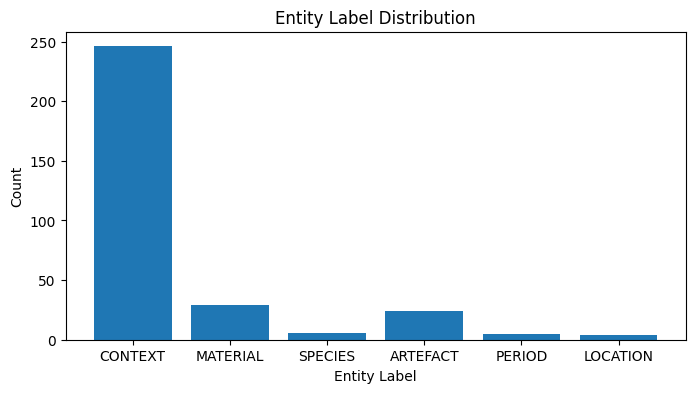

In [106]:
# Read the all.iob file
all_iob_path = "../data/train_data/test.iob"

with open(all_iob_path, encoding="utf-8") as f:
    lines = f.read().splitlines()

# Parse into sentences (list of list of (token, tag))
sentences = []
current = []
for line in lines:
    if line.strip() == "":
        if current:
            sentences.append(current)
            current = []
    else:
        parts = line.split()
        if len(parts) == 2:
            token, tag = parts
            current.append((token, tag))
if current:
    sentences.append(current)

# Suggestions for visualization:
# 1. Plot the distribution of entity labels (B-XXX, I-XXX) in the dataset.
# 2. Show example sentences with color-coded entities.
# 3. Plot sentence length distribution (number of tokens per sentence).
# 4. Show the most frequent entity types and their counts.
# 5. Visualize token/tag confusion matrix (for model evaluation).

# Example: Plot entity label distribution
import matplotlib.pyplot as plt
from collections import Counter

entity_tags = [tag for sent in sentences for _, tag in sent if tag != "O"]
entity_labels = [tag[2:] for tag in entity_tags if tag.startswith(("B-", "I-"))]
label_counts = Counter(entity_labels)

plt.figure(figsize=(8,4))
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Entity Label Distribution")
plt.xlabel("Entity Label")
plt.ylabel("Count")
plt.show()



In [108]:
from collections import Counter, defaultdict

def most_frequent_entities_by_label(df, n=10):
    """
    Print the n most frequent entity texts for each label in the DataFrame.
    """
    label_to_texts = defaultdict(list)
    for entities in df["entities"]:
        for ent in entities:
            label = ent["label"]
            text = ent["text"]
            label_to_texts[label].append(text)
    for label, texts in label_to_texts.items():
        print(f"\nLabel: {label}")
        for text, count in Counter(texts).most_common(n):
            print(f"  {text!r}: {count}")

# Example usage:
most_frequent_entities_by_label(df, n=10)


Label: ARTEFACT
  'pottery': 36
  'shells': 18
  'stones': 15
  'charcoal': 11
  'pottery sherds': 11
  'chipped stones': 11
  'ground stones': 7
  'clay building material': 6
  'chipped stone': 5
  'Pottery': 5

Label: CONTEXT
  'posthole': 81
  'pit': 58
  'wall': 51
  'trench': 40
  'c601': 30
  'cut': 17
  'fill': 17
  'C214': 17
  'burial': 15
  'c625': 15

Label: SPECIES
  'animal bones': 16
  'bones': 13
  'skeleton': 8
  'animal': 7
  'human': 7
  'ribs': 2
  'mouse': 1
  'skeleton c623': 1
  'young adult': 1
  'mandible': 1

Label: LOCATION
  'NW corner': 2
  'Northeast': 1
  'Northwest': 1
  'south of the trench': 1
  'Nwcorner': 1
  'Toumba hill': 1
  'site': 1
  'river side': 1
  'NE side': 1
  'sector H3-82': 1

Label: MATERIAL
  'CBM': 64
  'charcoal': 12
  'stones': 10
  'limestone': 7
  'clay': 5
  'clay building material': 5
  'mud': 4
  'flint': 4
  'glass': 3
  'stone': 3

Label: PERIOD
  'late neolithic II': 7
  'neolithic': 5
  'late neolithic': 4
  'last season':

## Export to Argilla

### Recreate dataset records

In [109]:
# Add this utility function anywhere before you use entities (e.g., before paragraph_to_sentence_iobs or before saving entities):

def filter_entities_by_offset(entities, text):
    """
    Remove entities where end <= start.
    Accepts a list of dicts or pydantic Entity objects.
    """
    filtered = []
    text_len = len(text)

    for ent in entities:
        if 0 <= ent["start"] < ent["end"] <= text_len:
            filtered.append(ent)
    return filtered

def fix_entity_offsets(entities, paragraph):
    """
    For each entity, find the correct start and end offsets of entity["text"] in the paragraph.
    If multiple entities have the same text, finds the next occurrence after the previous one.
    Returns a new list of entities with corrected offsets.
    """
    import re
    fixed_entities = []
    last_end = 0
    for ent in entities:
        ent_dict = ent.model_dump() if hasattr(ent, "model_dump") else dict(ent)
        text = ent_dict["text"]
        # Search for the entity text in the paragraph after last_end
        match = re.search(re.escape(text), paragraph[last_end:])
        if match:
            start = last_end + match.start()
            end = last_end + match.end()
            ent_dict["start"] = start
            ent_dict["end"] = end
            fixed_entities.append(ent_dict)
            last_end = end
        else:
            # If not found, skip or keep original (optional: log warning)
            continue
    return fixed_entities

dataset_name = "atrium_context_sheet_descriptions"
workspace_name = "atrium"

# Access the environment variables
argilla_api_url = os.environ['ARGILLA_API_URL']
argilla_api_key = os.environ['ARGILLA_API_KEY']
client = rg.Argilla(
    api_url=argilla_api_url,
    api_key=argilla_api_key
)
logger.info(client.me)
recreate = True
if recreate:    

    with open("../data/archaeobert_ner_gudelines_mt_translation.md") as inf:
        guidelines = inf.read()  
    
    workspaces = client.workspaces
    workspaces_to_create = [
            {"name":"atrium", "users_to_add":["prokopis"]},
                           ]
    for workspace_to_create in workspaces_to_create:
        try:
            created_workspace = rg.Workspace(name=workspace_to_create["name"]).create()
        except:
            pass
        for user_to_add in workspace_to_create["users_to_add"]:
            user_to_add = client.users(user_to_add)
            try: 
                logger.info(user_to_add)
                user_to_add.add_to_workspace(client.workspaces(workspace_to_create["name"]))
                #added_user = rg.Workspace(name=workspace_to_create["name"]).add_user(user_to_add)
            except:
                pass

    for workspace in workspaces:    
        for user in workspace.users:
            logger.debug(f"Workspace: {workspace.name}, User:{user.username}, UserId:{user.id}")


if recreate:
    settings = rg.Settings(
        guidelines= guidelines,
        fields=[
            rg.TextField(
                name="context_sheet_description_field",
                title="Context sheet description",
                required=True,                
            ),
        ],
        metadata=[
            rg.IntegerMetadataProperty(
                name="context_sheet_description_id",
                title="Context sheet description id",
                visible_for_annotators=True,
            ),
            rg.TermsMetadataProperty(
                name="long_paragraph",
                title="Long Paragraph",
                visible_for_annotators=True,
            ),
        ],
        questions=[
            rg.SpanQuestion(
                name="entities",
                title="Entities",
                field="context_sheet_description_field",
                labels=['PERIOD', 'ARTEFACT', 'CONTEXT', 'SPECIES', 'MATERIAL', "LOCATION", "FEATURE",
                        "MISC",
                       ],
                description = """Annotate text spans that should be recognized as entities of interest with one of these labels. 
                If one of these labels is not appropriate, use the MISC label and suggest in the label_suggestion text box a new label.""",
                allow_overlapping=True,
            ),
            rg.TextQuestion(
                name="label_suggestion",
                title="Label suggestion",
                description = """If you have used MISC as a label, suggest here a new label in the form of {"text1": "new_label", "text2": "new_label", etc}.""",
            ),
            # rg.TextQuestion(
            #     name="entity_canonical_version",
            #     title="Entity canonical version",
            #     description = """You can add here a link to an authoritative vocabulary (PERIODO, GETTY AAT, GETTY TGN, etc) entry for this entity.""",
            # ),
        ],
    )
    
    dataset = rg.Dataset(
        name=dataset_name,
        workspace=workspace_name, 
        settings=settings,
        client=client,
    )
    
    for cdataset in client.datasets:
        if cdataset.name==dataset_name:
            cdataset.delete()
    dataset.create()


if recreate:
    records = list()
    for idx, row in  tqdm(df .iterrows(), total=df.shape[0]):
    #for idx, row in  df.sample(n=10, random_state=42).iterrows():
        context_sheet_description_field = row["paragraph"]
        if not "neolithic" in context_sheet_description_field:
            pass
        
        entities = fix_entity_offsets(row["entities"], row["paragraph"])        
        entities = filter_entities_by_offset(entities, context_sheet_description_field)

        try:
            long_paragraph = False
            if idx in df_long_idx_list:
                long_paragraph = True
            record = rg.Record(
                fields = {
                        "context_sheet_description_field": context_sheet_description_field,
                    },
                metadata = {
                        "context_sheet_description_id":  idx,
                        "long_paragraph":  long_paragraph,
                    },
                suggestions = [
                    rg.Suggestion(question_name="entities", value=entities),
                    rg.Suggestion(question_name="label_suggestion", value=""),
                    #rg.Suggestion(question_name="entity_canonical_version", value="")
                ]                    
            )
            records.append(record)
        except:
            logger.info( f'Idx: {idx}  {row["paragraph"][23:38] }' )
            traceback.print_exc()
            # break
    
    logger.info(f"Number of records to log: {len(records)}")

    if records:
        logger.info(f"Number of records to log: {len(records)}")
        status_filter = rg.Query(
            filter = rg.Filter(("response.status", "==", "pending"))
        )

        # logger.info(records)
        try:
            try:
                records_to_delete = list(dataset.records(status_filter))
                #dataset.records.delete(records_to_delete)
            except:
                pass
            dataset.records.log(records)
        except:
            traceback.print_exc()
            pass


logger.debug("FINISHED")

2025-10-08 02:18:09 INFO HTTP Request: GET https://nlp.ilsp.gr/argilla/api/v1/me "HTTP/1.1 200 OK"
2025-10-08 02:18:09 INFO UsersAPI: Got user prokopis
2025-10-08 02:18:09 INFO Argilla: Logged in as prokopis with the role Role.owner
2025-10-08 02:18:09 INFO HTTP Request: GET https://nlp.ilsp.gr/argilla/api/v1/me "HTTP/1.1 200 OK"
2025-10-08 02:18:09 INFO UsersAPI: Got user prokopis
2025-10-08 02:18:09 INFO User(id=UUID('ec0782d8-0bd6-4b6a-bc4b-ebbf88bc1429') inserted_at=datetime.datetime(2025, 5, 11, 12, 7, 59, 283793) updated_at=datetime.datetime(2025, 5, 11, 12, 7, 59, 283793) username='prokopis' role=<Role.owner: 'owner'> first_name='Prokopis' last_name='Prokopidis' password=None)
2025-10-08 02:18:09 INFO HTTP Request: POST https://nlp.ilsp.gr/argilla/api/v1/workspaces "HTTP/1.1 409 Conflict"
2025-10-08 02:18:09 INFO HTTP Request: GET https://nlp.ilsp.gr/argilla/api/v1/users "HTTP/1.1 200 OK"
2025-10-08 02:18:09 INFO UsersAPI: Listed 10 users
2025-10-08 02:18:09 INFO User(id=UUID('e

  0%|          | 0/584 [00:00<?, ?it/s]

2025-10-08 02:18:10 INFO Number of records to log: 584
2025-10-08 02:18:10 INFO Number of records to log: 584
2025-10-08 02:18:10 INFO HTTP Request: GET https://nlp.ilsp.gr/argilla/api/v1/datasets/53647a3c-db23-41be-a557-d1938af7760d "HTTP/1.1 200 OK"
2025-10-08 02:18:10 INFO HTTP Request: POST https://nlp.ilsp.gr/argilla/api/v1/datasets/53647a3c-db23-41be-a557-d1938af7760d/records/search?offset=0&limit=256&include=suggestions&include=responses "HTTP/1.1 200 OK"
Sending records...:   0%|          | 0/2 [00:00<?, ?batch/s]2025-10-08 02:18:10 INFO DatasetRecords: Sending records from 0 to 256.
2025-10-08 02:18:13 INFO HTTP Request: PUT https://nlp.ilsp.gr/argilla/api/v1/datasets/53647a3c-db23-41be-a557-d1938af7760d/records/bulk "HTTP/1.1 200 OK"
2025-10-08 02:18:13 INFO RecordsAPI: Updated 0 records and create 256 records in dataset 53647a3c-db23-41be-a557-d1938af7760d
Sending records...:  50%|█████     | 1/2 [00:02<00:02,  2.24s/batch]2025-10-08 02:18:13 INFO DatasetRecords: Sending rec

# Start finetuning the model


In [ ]:
# 1. Define the columns of our dataset
columns = {0: 'text', 1: 'ner'}

# this is the folder in which train, test and dev files reside

from flair.data import Corpus
from flair.embeddings import TransformerWordEmbeddings
from flair.models import SequenceTagger
from flair.trainers import ModelTrainer
from flair.datasets import ColumnCorpus
from flair.visual.training_curves import Plotter
from flair.data import Sentence
from joblib import Parallel, delayed
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
import flair
import torch

if torch.cuda.is_available():
    flair.device = torch.device('cuda:2')
else:
    flair.device = torch.device('cpu')

retrain = True

if retrain:
    project_basename=data_dir.name
    DATA_FOLDER = train_data_dir
    TRAIN_FOLDER = train_dir 
    logger.info(DATA_FOLDER)
    logger.info(TRAIN_FOLDER)
    TRAIN_FOLDER.mkdir(exist_ok=True)
    DATA_FOLDER.mkdir(exist_ok=True)

    # retrieve corpus using column format, data folder and the names of the train, dev and test files
    corpus: Corpus = ColumnCorpus(DATA_FOLDER, columns,
                                                    train_file=f'train.iob',
                                                    test_file=f'test.iob',
                                                    dev_file=f'dev.iob',
                                                    )
    print(corpus)
    # stats = corpus.obtain_statistics()
    # print(stats)    
    ## 2. Which label do we want to predict?
    label_type = 'ner'


    # 3. make the label dictionary from the corpus
    label_dict = corpus.make_label_dictionary(label_type=label_type)
    print(label_dict)    


    # 4. initialize fine-tuneable transformer embeddings WITH document context
    embeddings = TransformerWordEmbeddings(model='xlm-roberta-large',
                                        layers="-1",
                                        subtoken_pooling="first",
                                        fine_tune=True,
                                        use_context=False,
                                        transformers_tokenizer_kwargs={'model_max_length': 512}  ## tokenizer params
                                        )    
    """
            Sequence Tagger class for predicting labels for single tokens. Can be parameterized by several attributes.
            In case of multitask learning, pass shared embeddings or shared rnn into respective attributes.
            :param embeddings: Embeddings to use during training and prediction
            :param tag_dictionary: Dictionary containing all tags from corpus which can be predicted
            :param tag_type: type of tag which is going to be predicted in case a corpus has multiple annotations
            :param use_rnn: If true, use a RNN, else Linear layer.
            :param rnn: (Optional) Takes a torch.nn.Module as parameter by which you can pass a shared RNN between
                different tasks.
            :param rnn_type: Specifies the RNN type to use, default is 'LSTM', can choose between 'GRU' and 'RNN' as well.
            :param hidden_size: Hidden size of RNN layer
            :param rnn_layers: number of RNN layers
            :param bidirectional: If True, RNN becomes bidirectional
            :param use_crf: If True, use a Conditional Random Field for prediction, else linear map to tag space.
            :param reproject_embeddings: If True, add a linear layer on top of embeddings, if you want to imitate
                fine tune non-trainable embeddings.
            :param dropout: If > 0, then use dropout.
            :param word_dropout: If > 0, then use word dropout.
            :param locked_dropout: If > 0, then use locked dropout.
            :param train_initial_hidden_state: if True, trains initial hidden state of RNN
            :param loss_weights: Dictionary of weights for labels for the loss function
                (if any label's weight is unspecified it will default to 1.0)
            :param init_from_state_dict: Indicator whether we are loading a model from state dict
                since we need to transform previous models' weights into CRF instance weights
    """

    # 5. initialize bare-bones sequence tagger (no CRF, no RNN, no reprojection)
    tagger = SequenceTagger(hidden_size=256,
                            embeddings=embeddings,
                            tag_dictionary=label_dict,
                            tag_type='ner',
                            use_crf=False,
                            use_rnn=False,
                            reproject_embeddings=False,
                            )    
    # 6. initialize trainer
    trainer = ModelTrainer(tagger, corpus)    
    # 7. run fine-tuning 
    # Use a modern GPU for fine-tuning
    trainer.fine_tune(TRAIN_FOLDER,
                    learning_rate=5.0e-6,
                    mini_batch_size=8,
                    max_epochs = 150,
                    #mini_batch_chunk_size=1,  # remove this parameter to speed up computation if you have a big GPU
                    use_final_model_for_eval=False,
                    )
    logger.info("Finished training")    


# Summary